In [27]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
spark = SparkSession.builder \
    .appName("MySparkApp") \
    .getOrCreate()

STEP 1 : DATA EXTRCTION 

In [3]:
df=(
   spark.read.format('csv').option('header','True').option('inferSchema','True').load('retail_black_friday_sales_100k.csv')
)

In [4]:
df.show()

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|      T0000001|    C007297|    26-35|  Male|San Francisco|           Loyal|     P2713|        Footwear|        153.73|          35|      99.92|       1|          99.92|   Credit Card|   2025-12-01|            0|         0|              0|
|      T0000002|    C001640|      56+| O

DATA TRANSFORMATION and DATA CLEANING

In [5]:
df.count()

100000

In [6]:
df.printSchema()

root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- city: string (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- original_price: double (nullable = true)
 |-- discount_pct: integer (nullable = true)
 |-- final_price: double (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- purchase_amount: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- purchase_date: date (nullable = true)
 |-- purchase_hour: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_black_friday: integer (nullable = true)



In [7]:
df.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in df.columns]
).show()

+--------------+-----------+---------+------+----+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|transaction_id|customer_id|age_group|gender|city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|
+--------------+-----------+---------+------+----+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|             0|          0|        0|     0|   0|               0|         0|               0|             0|           0|          0|       0|              0|             0|            0|            0|         0|              0|
+--------------+-----------+---------+------+----+----------------+---------

In [8]:
a=df.count()
b=df.distinct().count()
print("duplicates:",a-b)

duplicates: 0


In [9]:
df.drop_duplicates()

DataFrame[transaction_id: string, customer_id: string, age_group: string, gender: string, city: string, customer_segment: string, product_id: string, product_category: string, original_price: double, discount_pct: int, final_price: double, quantity: int, purchase_amount: double, payment_method: string, purchase_date: date, purchase_hour: int, is_weekend: int, is_black_friday: int]

In [10]:
# Normalize sales-related columns

df=df.withColumn("Purchase", col("purchase_amount").cast("int"))

In [11]:
# Standardize categorical text columns
df.withColumn("Category", trim(lower(col("product_category")))).show(5)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+---------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|Purchase| Category|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+---------+
|      T0000001|    C007297|    26-35|  Male|San Francisco|           Loyal|     P2713|        Footwear|        153.73|          35|      99.92|       1|          99.92|   Credit Card|   2025-12-01|            0|         0|

In [12]:
#Discount_Percentage-Percentage discount applied

df=df.withColumn("Discount_Percentage", col('discount_pct').cast('double'))

In [13]:

## Revenue_Per_Customer
df=df.withColumn("Revenue_Per_Customer",col('original_price')-col('final_price'))



In [14]:
## High_Value_Order_Flag - 1 if order exceeds threshold
df=df.withColumn("High_Value_Order_Flag", when(col("Purchase") > 100, 1).otherwise(0))

 Weekend_Sale_Flag -- 1 if transaction occurred on weekend
 already available as 'is_weekend' column

In [15]:
## Product_Category_Count -- Number of product categories purchased
df=df.withColumn("Product_Category_Count", count("product_category").over(Window.partitionBy('customer_id')))

## Advanced Transformations

In [16]:
#Aggregate category-level sales
df.groupBy('product_category').agg(sum('Purchase').alias('Total_Sales')).orderBy(desc('Total_Sales')).show(5)

+----------------+-----------+
|product_category|Total_Sales|
+----------------+-----------+
|     Electronics|   14118520|
|  Home & Kitchen|    6456256|
|          Sports|    3298662|
|     Accessories|    2749540|
|        Footwear|    2008343|
+----------------+-----------+
only showing top 5 rows


In [17]:
## Build customer purchase frequency tables

df.groupBy('customer_id').agg(count('Purchase').alias('purchase_frequency')).orderBy(desc('purchase_frequency')).show(5)

df.show(5)

+-----------+------------------+
|customer_id|purchase_frequency|
+-----------+------------------+
|    C016694|                12|
|    C019611|                11|
|    C005664|                11|
|    C013580|                10|
|    C032741|                10|
+-----------+------------------+
only showing top 5 rows
+--------------+-----------+---------+------+-----------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+---------------------+----------------------+
|transaction_id|customer_id|age_group|gender|       city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|Purchase|Discount_Percentage|Revenue_Per_Customer|High_Value_Order_Flag|Product_Category_Count|
+------------

In [18]:
## Create city-level sales statistics
df.groupBy('city').agg(sum('Purchase').alias('Total_Sales'), avg('Purchase').alias('Avg_Sales')).orderBy(desc('Total_Sales')).show(5)

+--------+-----------+------------------+
|    city|Total_Sales|         Avg_Sales|
+--------+-----------+------------------+
| Atlanta|    3613414| 358.6515136476427|
|   Miami|    3561872|354.90952570745316|
|  Dallas|    3543061|354.66076076076075|
|New York|    3541513| 350.4713508164275|
| Phoenix|    3521107| 350.9875398724083|
+--------+-----------+------------------+
only showing top 5 rows


In [19]:
## Rank top-selling products using window functions
window_spec = Window.partitionBy('product_category').orderBy(desc('Purchase'))
df=df.withColumn('Sales_Rank', rank().over(window_spec))

In [20]:
df.show(5)

+--------------+-----------+---------+------+-----------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+---------------------+----------------------+----------+
|transaction_id|customer_id|age_group|gender|       city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|Purchase|Discount_Percentage|Revenue_Per_Customer|High_Value_Order_Flag|Product_Category_Count|Sales_Rank|
+--------------+-----------+---------+------+-----------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+---------------------+---

## Use Case 3 — Product & Inventory Insights

Phase 1 : Business Problem

In [ ]:
## Detect high-demand products
df.filter(col('Sales_Rank') == 1).show(10)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+---------------------+----------------------+----------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|Purchase|Discount_Percentage|Revenue_Per_Customer|High_Value_Order_Flag|Product_Category_Count|Sales_Rank|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+-------------------

In [35]:
## Analyze category growth trends
growth_trends=df.groupBy('product_category', year('purchase_date').alias('year')).agg(sum('Purchase').alias('Total_Sales')).orderBy('year', desc('Total_Sales'))
growth_trends.show(5)

+----------------+----+-----------+
|product_category|year|Total_Sales|
+----------------+----+-----------+
|     Electronics|2025|   14118520|
|  Home & Kitchen|2025|    6456256|
|          Sports|2025|    3298662|
|     Accessories|2025|    2749540|
|        Footwear|2025|    2008343|
+----------------+----+-----------+
only showing top 5 rows


In [24]:
## Compute rolling sales averages
window_spec = Window.partitionBy('product_category').orderBy('purchase_date').rowsBetween(0,6)
df.withColumn('Rolling_Avg_Sales',avg('Purchase').over(window_spec)).show(5)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+---------------------+----------------------+----------+------------------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|Purchase|Discount_Percentage|Revenue_Per_Customer|High_Value_Order_Flag|Product_Category_Count|Sales_Rank| Rolling_Avg_Sales|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--

In [29]:
## Identify seasonal purchasing patterns
month_sales=df.groupBy(month('purchase_date').alias('month')).agg(sum('Purchase').alias('Total_Sales')).orderBy('month')

## Visualizations

Visual 1 — Monthly Sales Trends

<Axes: xlabel='month', ylabel='Total_Sales'>

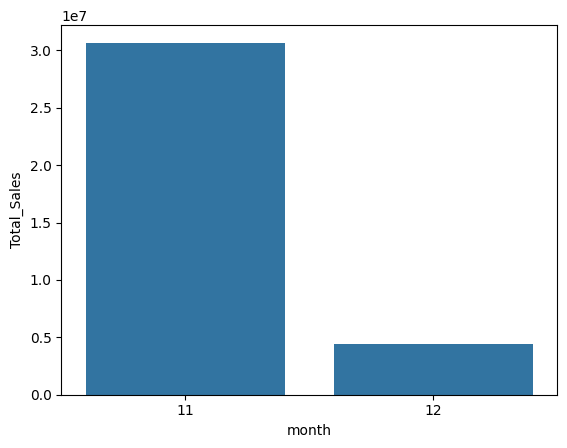

In [ ]:
## Suggested Visualization:
##Line Chart


sns.barplot(data=month_sales.toPandas(), x='month', y='Total_Sales')


Visual 2 — Fastest Growing Categories
Suggested Visualization:
Multi-Line Trend Graph


<Axes: xlabel='year', ylabel='Total_Sales'>

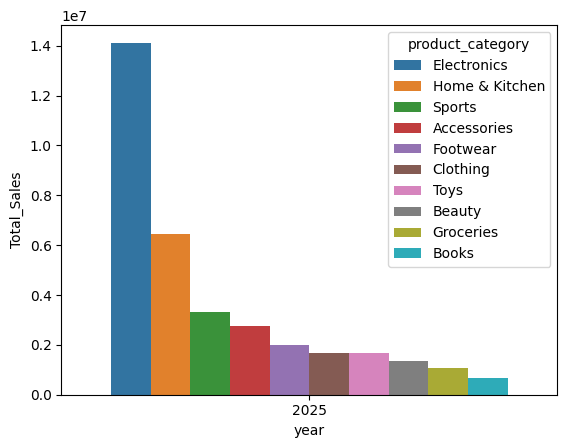

In [38]:
## Suggested Visualization:
# Multi-Line Trend Graph

sns.barplot(data=growth_trends.toPandas(), x='year', y='Total_Sales', hue='product_category')


Visual 3 — Seasonal Purchase Distribution

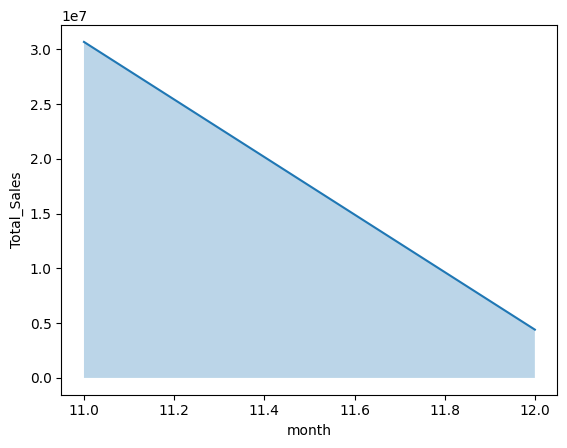

In [34]:
## Visual 3 — Seasonal Purchase Distribution
##Suggested Visualization:
##Area Chart

sns.lineplot(data=month_sales.toPandas(), x='month', y='Total_Sales')
plt.fill_between(month_sales.toPandas()['month'], month_sales.toPandas()['Total_Sales'], alpha=0.3)
